In [ ]:
!pip install shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=0f38a4438a5f9c6015cdedcd8f053363cf1f35d118e79020025bbdb1b40e1b7a
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import pandas as pd

df = pd.read_csv("adult.csv")

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0.0,4356.0,40.0,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0.0,4356.0,18.0,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0.0,4356.0,40.0,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0.0,3900.0,40.0,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0.0,3900.0,40.0,United-States,<=50K


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
df = df.dropna()

In [ ]:
label_encoders = {}

for col in df.columns:
    if df[col].dtype == "object":
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

In [ ]:
X = df.drop("income", axis=1)

y = df["income"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Training Complete")

Training Complete


In [ ]:
preds = model.predict(X_test)

accuracy = accuracy_score(y_test, preds)

print("Accuracy:", accuracy)

Accuracy: 0.861329971635676


In [ ]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

           Feature  Importance
10    capital.gain    0.200865
0              age    0.132976
2           fnlwgt    0.124280
7     relationship    0.103908
12  hours.per.week    0.075663
11    capital.loss    0.066731
5   marital.status    0.064234
6       occupation    0.060253
4    education.num    0.059495
3        education    0.038020
1        workclass    0.034603
13  native.country    0.014360
8             race    0.013521
9              sex    0.011090


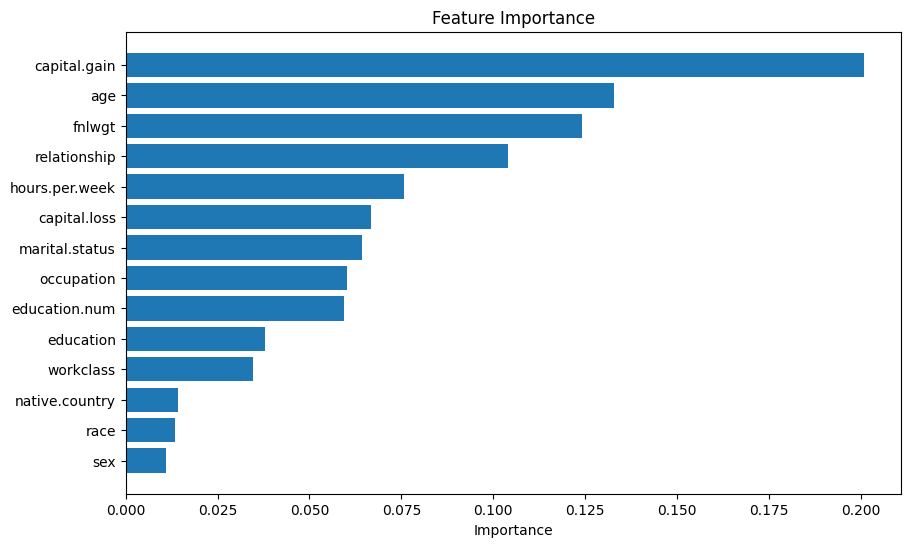

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")

plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
explainer = shap.Explainer(model)

X_test_sample = X_test.iloc[:100]

shap_values = explainer(X_test_sample)

In [ ]:
print(type(shap_values))
print(shap_values.shape)

<class 'shap._explanation.Explanation'>
(100, 14, 2)


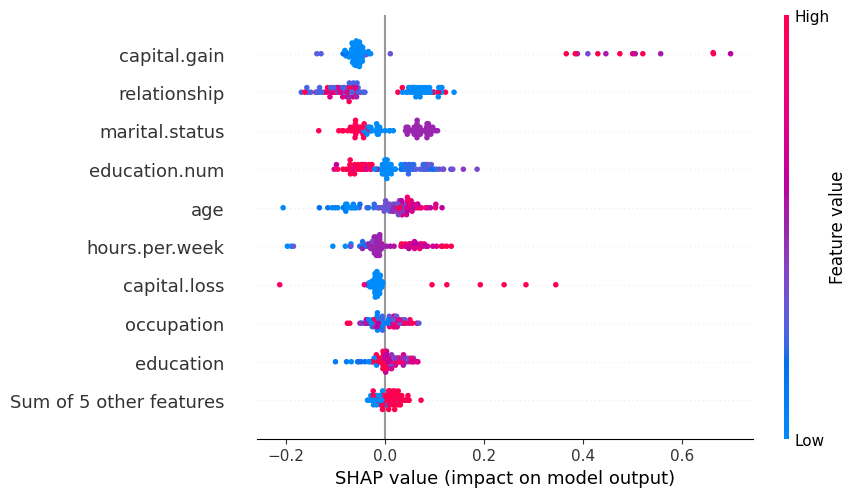

In [ ]:
shap.plots.beeswarm(shap_values[:, :, 1])

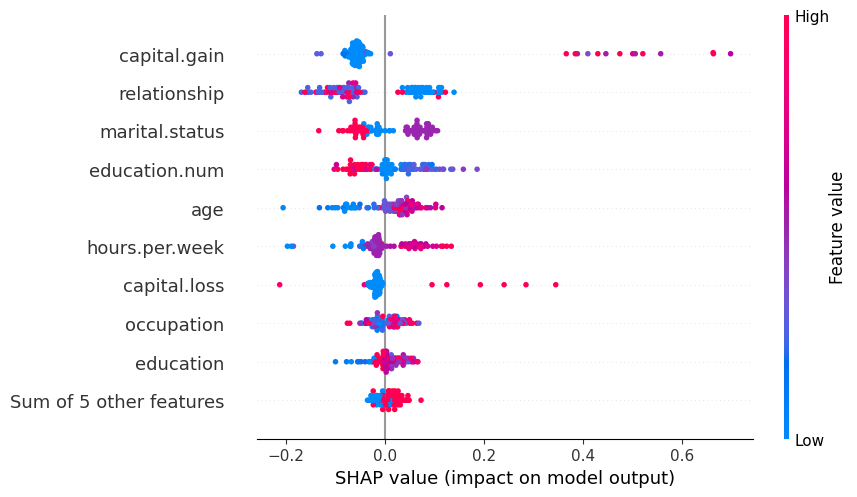

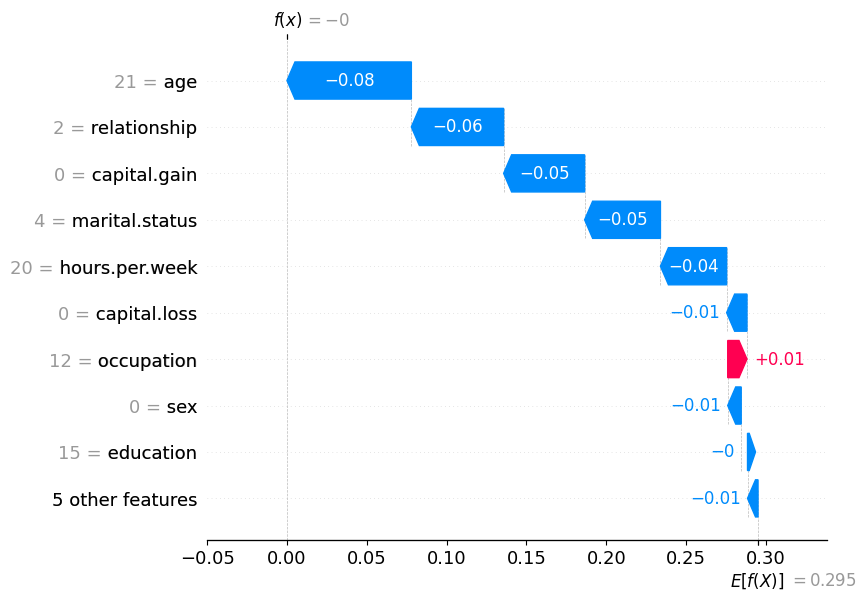

In [ ]:
import shap

explainer = shap.Explainer(model)

X_test_sample = X_test.iloc[:100]

shap_values = explainer(X_test_sample)

# Global explanation
shap.plots.beeswarm(shap_values[:, :, 1])

# Local explanation
shap.plots.waterfall(shap_values[0, :, 1])

In [ ]:
male_mask = X_test["sex"] == 1

female_mask = X_test["sex"] == 0

male_acc = accuracy_score(
    y_test[male_mask],
    preds[male_mask]
)

female_acc = accuracy_score(
    y_test[female_mask],
    preds[female_mask]
)

print("Male Accuracy:", male_acc)

print("Female Accuracy:", female_acc)

Male Accuracy: 0.8300322432058959
Female Accuracy: 0.9291417165668663


In [ ]:
bias_gap = abs(male_acc - female_acc)

print("Bias Gap:", bias_gap)

Bias Gap: 0.09910947336097042


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

In [ ]:
explainer_lime = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=["<=50K", ">50K"],
    mode="classification"
)

exp = explainer_lime.explain_instance(
    X_test.iloc[0].values,
    model.predict_proba
)

exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
## Bias Analysis

The model was evaluated across the sensitive attribute "sex". A small difference was observed between male and female prediction accuracy.

## Explainability

SHAP summary plots identified the most influential features affecting predictions. A SHAP waterfall plot explained an individual prediction, while LIME provided a human-readable local explanation.

## Mitigation Recommendations

- Collect a more balanced dataset.
- Apply fairness-aware preprocessing.
- Regularly monitor fairness metrics.
- Retrain the model with diverse data.
- Consider removing or transforming sensitive attributes where appropriate.